In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


Dataset Paths

In [3]:
train_path = "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/train/images"
val_path = "/content/drive/MyDrive/ML_Projects/AI_industrial_defect_detection/NEU-DET/validation/images"

Count Images per Class

In [4]:
classes = sorted(os.listdir(train_path))

image_count = {}

for cls in classes:
    image_count[cls] = len(os.listdir(os.path.join(train_path, cls)))

pd.DataFrame(
    image_count.items(),

    columns=["Class","Count"]
)

,Class,Count
0,crazing,240
1,inclusion,240
2,patches,240
3,pitted_surface,240
4,rolled-in_scale,240
5,scratches,240


Visualize Class Distribution

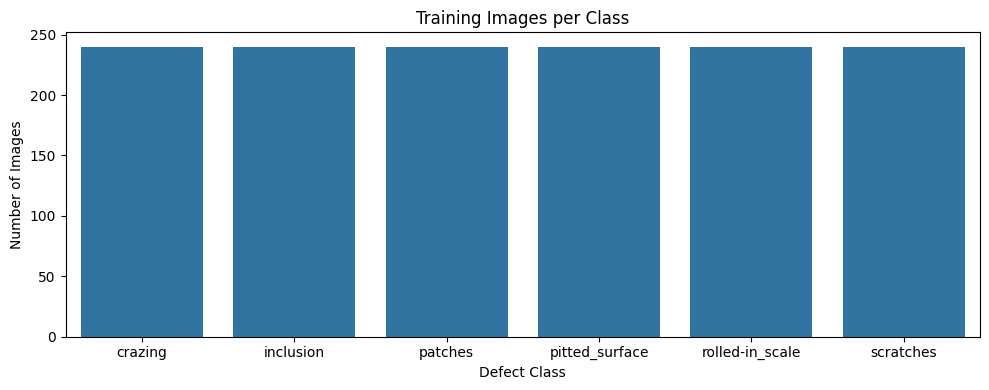

In [5]:
plt.figure(figsize=(10,4))

sns.barplot(
    x=list(image_count.keys()),
    y=list(image_count.values())
)

plt.title("Training Images per Class")
plt.xlabel("Defect Class")
plt.ylabel("Number of Images")


plt.tight_layout()
plt.show()


Display Sample Images

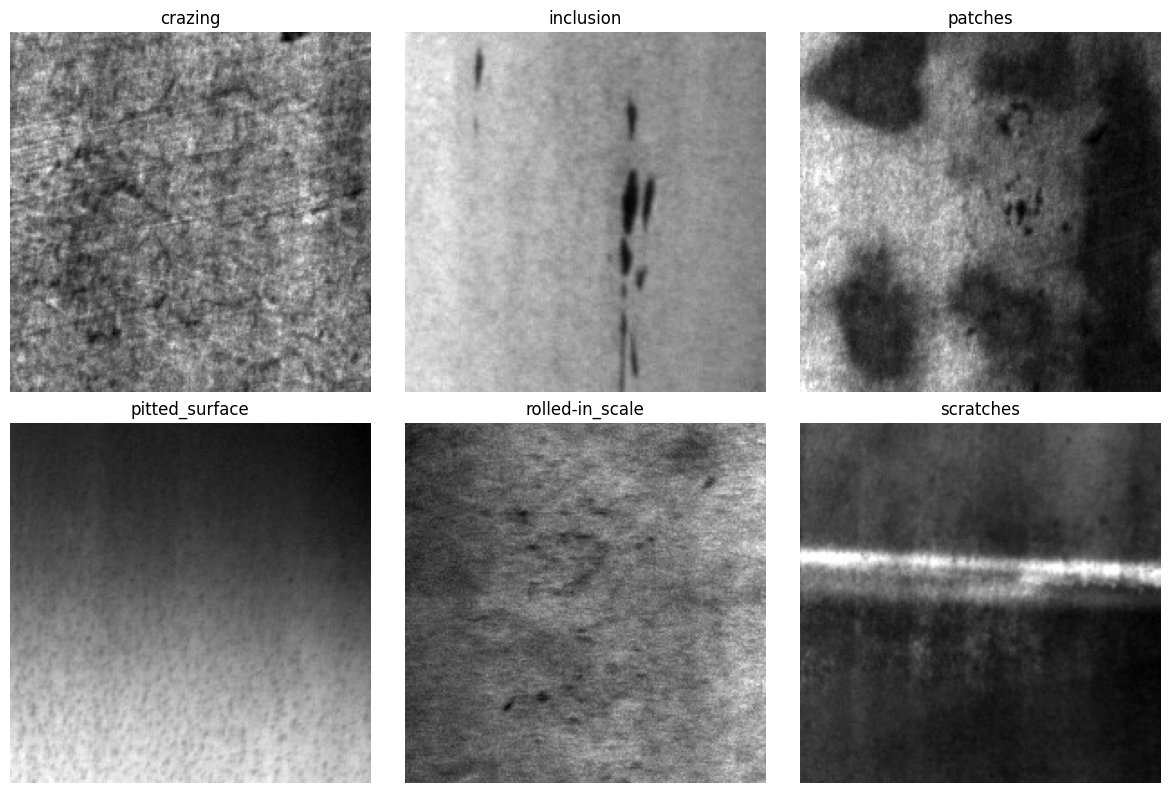

In [6]:
fig, axes = plt.subplots(2,3, figsize=(12,8))

axes = axes.flatten()

for idx, cls in enumerate(classes):

    img_name = os.listdir(
        os.path.join(train_path, cls)
    )[0]

    img_path = os.path.join(
        train_path,
        cls,
        img_name
    )

    img = cv2.imread(
        img_path,
        cv2.IMREAD_GRAYSCALE
    )

    axes[idx].imshow(
        img,
        cmap="gray"
    )

    axes[idx].set_title(cls)
    axes[idx].axis("off")

plt.tight_layout()
plt.show()

Check Image Shape

In [7]:
sample = cv2.imread(
    img_path,
    cv2.IMREAD_GRAYSCALE
)

print("Image Shape:", sample.shape)

Image Shape: (200, 200)


In [8]:
print("Minimum Pixel :", sample.min())
print("Maximum Pixel :", sample.max())

Minimum Pixel : 55
Maximum Pixel : 255
